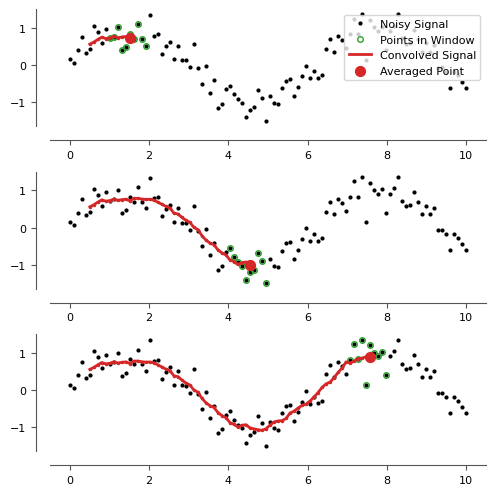

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mylib.fig_tools import adjust_general

# Generate a noisy signal
np.random.seed(42)
n_points = 100
x = np.linspace(0, 10, n_points)
clean_signal = np.sin(x)
noisy_signal = clean_signal + np.random.normal(0, 0.3, n_points)

# Define a block (boxcar) kernel
kernel_size = 10
kernel = np.ones(kernel_size) / kernel_size

# Perform the full convolution
convolved_signal = np.convolve(noisy_signal, kernel, mode='valid')
conv_x = x[kernel_size//2 : -kernel_size//2 + 1] # approximate alignment

# Setup the figure for multiple panels
fig, axes = plt.subplots(3, 1, figsize=(5,5), sharex=True)
snapshots = [10, 40, 70] # indices where we want to visualize the kernel

for i, ax in enumerate(axes):
    idx = snapshots[i]
    
    # Plot the noisy signal
    ax.plot(x, noisy_signal, '.', color='k', label='Noisy Signal', markersize=4)
    
    # Plot the kernel at the current position
    # The kernel covers indices idx to idx + kernel_size
    kernel_x = x[idx : idx + kernel_size]
    kernel_y = noisy_signal[idx : idx + kernel_size]
    
    # Highlight the points within the window
    ax.plot(kernel_x, kernel_y, '.', color='C2', markerfacecolor='None', label='Points in Window', markersize=8)
    
    # Highlight the point being computed
    calc_idx = idx + kernel_size // 2
    ax.plot(conv_x[:idx+1], convolved_signal[:idx+1], 
            color='C3', linewidth=2, label='Convolved Signal')
    ax.plot(conv_x[:idx+1], convolved_signal[:idx+1], '.', color='C3')
    ax.scatter([conv_x[idx]], [convolved_signal[idx]], color='C3', s=50, zorder=5, label='Averaged Point') # Compute point
    
    adjust_general(ax)
#     ax.set_title(f'Convolution Step at index {calc_idx}')
    if i == 0:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('figures/convolution.png', dpi = 300)

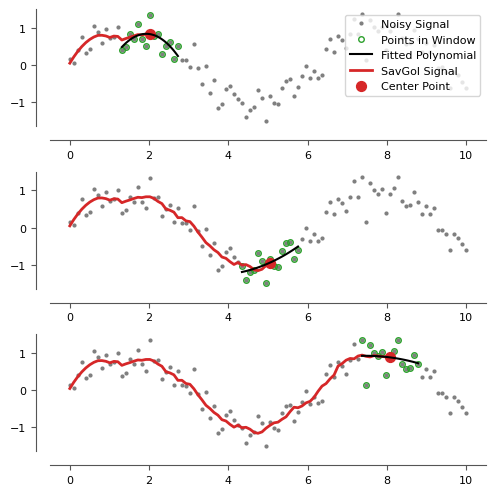

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mylib.fig_tools import adjust_general
from scipy.signal import savgol_filter

# Generate the same noisy signal
np.random.seed(42)
n_points = 100
x = np.linspace(0, 10, n_points)
clean_signal = np.sin(x)
noisy_signal = clean_signal + np.random.normal(0, 0.3, n_points)

# Savitzky-Golay parameters
window_length = 15
polyorder = 2
half_window = window_length // 2

# Compute the full smoothed signal for the trail
smoothed_signal = savgol_filter(noisy_signal, window_length, polyorder)

# Setup the figure for multiple panels
fig, axes = plt.subplots(3, 1, figsize=(5, 5), sharex=True)
snapshots = [20, 50, 80] # indices for the center of the sliding window

for i, ax in enumerate(axes):
    center_idx = snapshots[i]
    start_idx = center_idx - half_window
    end_idx = center_idx + half_window + 1
    
    # Plot the full noisy signal
    ax.plot(x, noisy_signal, '.', color='tab:grey', label='Noisy Signal', markersize=4)
    
    # Extract points inside the current window
    window_x = x[start_idx:end_idx]
    window_y = noisy_signal[start_idx:end_idx]
    
    # Highlight the points within the window
    ax.plot(window_x, window_y, '.', color='C2', markerfacecolor='None', 
            label='Points in Window', markersize=8)
    
    # Compute the local polynomial fit to demonstrate the Savitzky-Golay concept
    coeffs = np.polyfit(window_x, window_y, polyorder)
    x_fit = np.linspace(window_x[0], window_x[-1], 50)
    y_fit = np.polyval(coeffs, x_fit)
    
    # Plot the local polynomial
    ax.plot(x_fit, y_fit, '-', color='k', label='Fitted Polynomial', zorder=100)
    
    # Center point from the polynomial fit
    center_x = x[center_idx]
    center_y = np.polyval(coeffs, center_x)
    
    # Plot the trail of the final smoothed signal up to this point
    ax.plot(x[:center_idx+1], smoothed_signal[:center_idx+1], 
            color='C3', linewidth=2, label='SavGol Signal')
    
    # Highlight the specific smoothed point derived from this window's polynomial
    ax.scatter([center_x], [center_y], color='C3', s=50, zorder=5, label='Center Point')
    
    adjust_general(ax)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('figures/savgol.png', dpi=300)

In [3]:
!pip install whittaker-eilers


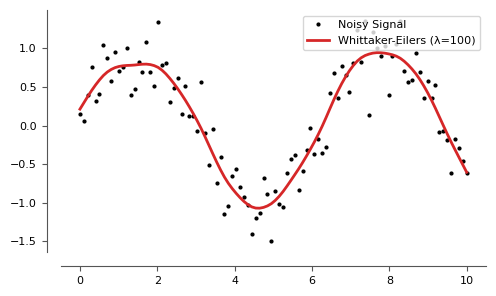

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
from mylib.fig_tools import adjust_general

def whittaker_smooth(y, lmbd, d=2):
    """
    Whittaker-Eilers smoother.
    y: noisy signal
    lmbd: smoothing parameter
    d: difference order
    """
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1] # 1st order diff
    if d == 2:
        D = D[1:] - D[:-1] # 2nd order diff
    
    # (I + lmbd * D.T @ D) z = y
    W = sparse.eye(m, format='csc')
    A = W + lmbd * (D.T @ D)
    
    z = spsolve(A, y)
    return z

# Generate the same noisy signal
np.random.seed(42)
n_points = 100
x = np.linspace(0, 10, n_points)
clean_signal = np.sin(x)
noisy_signal = clean_signal + np.random.normal(0, 0.3, n_points)

# Apply Whittaker-Eilers smoothing
lambda_val = 100 # Smoothing parameter
smoothed_signal = whittaker_smooth(noisy_signal, lmbd=lambda_val, d=2)

# Setup the figure for a single panel
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Plot the noisy signal
ax.plot(x, noisy_signal, '.', color='k', label='Noisy Signal', markersize=4)

# Plot the smoothed signal
ax.plot(x, smoothed_signal, color='C3', linewidth=2, label=f'Whittaker-Eilers (λ={lambda_val})')

adjust_general(ax)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('figures/whittaker.png', dpi=300)
plt.show()

Optimal lambda found: 0.10


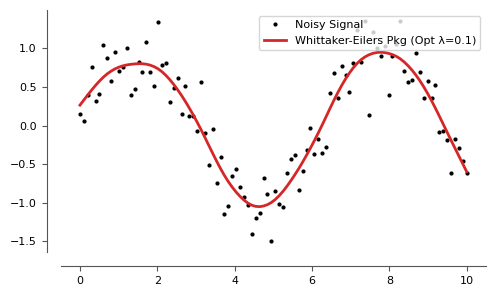

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mylib.fig_tools import adjust_general
from whittaker_eilers import WhittakerSmoother

# Generate the same noisy signal
np.random.seed(42)
n_points = 100
x = np.linspace(0, 10, n_points)
clean_signal = np.sin(x)
noisy_signal = clean_signal + np.random.normal(0, 0.3, n_points)

# Convert to list for the package
x_input = x.tolist()
data_to_smooth = noisy_signal.tolist()

# Setup WhittakerSmoother
whittaker_smoother = WhittakerSmoother(
    lmbda=100, order=2, data_length=len(data_to_smooth), x_input=x_input
)

# You can use smooth() or smooth_optimal() 
optimal_smooth = whittaker_smoother.smooth_optimal(data_to_smooth)
smoothed_signal_pkg = optimal_smooth.get_optimal().get_smoothed()
optimal_lambda = optimal_smooth.get_optimal().get_lambda()
print(f"Optimal lambda found: {optimal_lambda:.2f}")

# Setup the figure for a single panel
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Plot the noisy signal
ax.plot(x, noisy_signal, '.', color='k', label='Noisy Signal', markersize=4)

# Plot the smoothed signal
ax.plot(x, smoothed_signal_pkg, color='C3', linewidth=2, label=f'Whittaker-Eilers Pkg (Opt λ={optimal_lambda:.1f})')

adjust_general(ax)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('figures/whittaker_pkg.png', dpi=300)
plt.show()

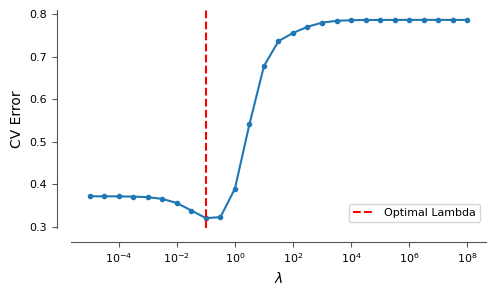

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Retrieve all tested lambdas and their cross validation errors
all_results = optimal_smooth.get_all()
tested_lambdas = [res.get_lambda() for res in all_results]
cv_errors = [res.get_cross_validation_error() for res in all_results]

# Plot the Cross Validation Error vs Lambdas
ax.plot(tested_lambdas, cv_errors, 'o-', color='C0')
ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('CV Error')
ax.axvline(optimal_smooth.get_optimal().get_lambda(), color='r', linestyle='--', label='Optimal Lambda')
ax.legend()
adjust_general(plt.gca())
plt.tight_layout()
plt.savefig('figures/CVE.png', dpi=300)